Accuracy: 0.9795763993948563
Accuracy: 0.9001512859304085
Accuracy: 0.8343419062027232


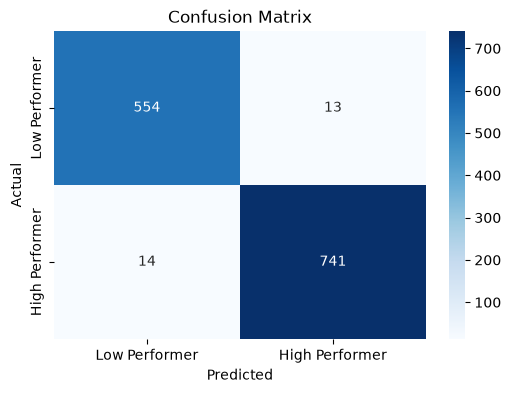

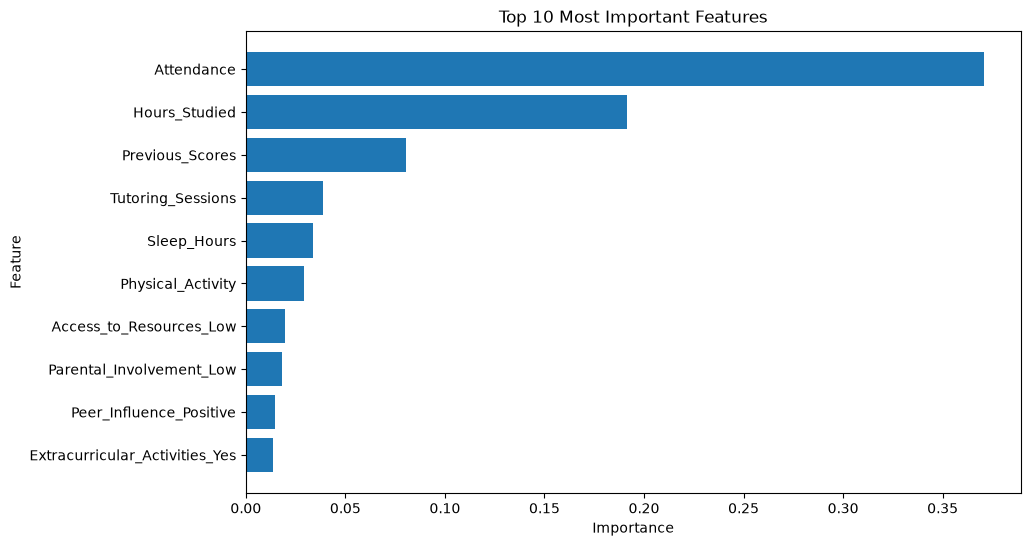

In [41]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Fill missing categorical values with the most frequent value

df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

df["Pass"] = (df["Exam_Score"] >= 70).astype(int)

df[["Exam_Score", "Pass"]].head()

median_score = df["Exam_Score"].median()

df["High_Performer"] = (
    df["Exam_Score"] >= median_score
).astype(int)


X = df.drop(["Exam_Score", "High_Performer", "Pass"], axis=1)

y = df["High_Performer"]



X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=1000,                   # Stronger regularization to prevent overfitting             # Robust solver for varied penalties                 # Use all CPU cores for speed
    random_state=42             # Ensure reproducible results
)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Accuracy:", accuracy_score(y_test, rf_pred))

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))



plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Performer", "High Performer"],
    yticklabels=["Low Performer", "High Performer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

top_features = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()

plt.show()



